# EDA – Eksplorativna analiza podataka: NLP za dating aplikacije

U sklopu drugog dijela projektnog zadatka urađena je eksplorativna analiza datasetova pripremljenih za šest NLP taskova: sistem preporučivanja, identifikaciju govora mržnje, detekciju prevara i botova, topic modeling, analizu sentimenta i emocija te generisanje icebreaker poruka.

Podaci su prikupljeni i obrađeni kroz pipeline s tri faze:

**Prikupljanje** — preuzeti su javno dostupni datasetovi: OkCupid profili s Kaggle-a, Davidson dataset govora mržnje s GitHuba kombinovan s `tweet_eval/hate` datasetom, SMS Spam Collection s UCI repozitorija, recenzije četiri dating aplikacije (Tinder, Bumble, Hinge, CMB) scraped sa Google Play Store-a te **PersonaChat** dataset s Hugging Face-a (izvor persona za icebreaker task).

**Sintetičko generisanje** — romance scam profili iz dating aplikacija nisu javno dostupni, pa je generisano 3000 bio profila (legitimnih i scam) i ~600 razgovora s labeliranim emocijama korištenjem šablona i Faker biblioteke. Za icebreaker task, bios i icebreaker poruke su generirani putem **Claude Haiku 4.5 API-ja** na osnovu PersonaChat persona, što omogućava raznovrsnije i prirodnije primjere od čisto šablonskog pristupa.

**Preprocesiranje** — tekst je očišćen (ftfy, Unicode normalizacija, zamjena URL-ova/e-mailova/telefona placeholder tokenima), tokenizovan i lematizovan. Korišćena su tri odvojena pipeline-a prilagodena različitim taskovima (embedding, klasifikacija, sentiment). Za taskove klasifikacije primijenjen je stratificirani train/val/test split (70/15/15).

Sve izlazne datoteke nalaze se u `data/processed/`.

In [6]:
import json
import sys
from collections import Counter
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
REPORTS = PROJECT_ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

print('Processed dir:', PROCESSED)
print('Reports dir:', REPORTS)
print('Fajlovi:', sorted(p.name for p in PROCESSED.glob('*.csv')))

Processed dir: c:\Users\zerina\Documents\dap\data\processed
Reports dir: c:\Users\zerina\Documents\dap\reports
Fajlovi: ['bios_for_embeddings.csv', 'bios_for_topics.csv', 'hate_speech_clean.csv', 'hate_speech_test.csv', 'hate_speech_train.csv', 'hate_speech_val.csv', 'scam_detection_clean.csv', 'scam_detection_test.csv', 'scam_detection_train.csv', 'scam_detection_val.csv', 'sentiment_conversations_clean.csv', 'sentiment_reviews_clean.csv', 'sentiment_reviews_test.csv', 'sentiment_reviews_train.csv', 'sentiment_reviews_val.csv']


## 1. Bio sekcije (preporuke + topic modeling)

In [7]:
bios = pd.read_csv(PROCESSED / 'bios_for_embeddings.csv')
print(bios.shape)
bios.head(3)

(57176, 20)


,profile_id,bio_raw,bio_clean,tokens_str,age,sex,orientation,status,body_type,diet,drinks,drugs,education,job,location,pets,religion,smokes,speaks,lang
0,0,about me: i would love to think that i was so...,about me: i would love to think that i was som...,would love think kind intellectual either dumb...,22,m,straight,single,a little extra,strictly anything,socially,never,working on college/university,transportation,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,sometimes,english,en
1,1,i am a chef: this is what that means. 1. i am ...,i am a chef: this is what that means 1 i am a ...,chef mean workaholic love cook regardless whet...,35,m,straight,single,average,mostly other,often,sometimes,working on space camp,hospitality / travel,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,no,"english (fluently), spanish (poorly), french (...",en
2,2,"i'm not ashamed of much, but writing public te...",i am not ashamed of much but writing public te...,not ashamed much but writing public text onlin...,38,m,straight,available,thin,anything,socially,NaN,graduated from masters program,NaN,"san francisco, california",has cats,NaN,no,"english, french, c++",en


Dataset sadrži **57 176** profila, preostatih nakon dvostepenog filtriranja — isključeni su profili kraći od 50 znakova i oni koji nisu na engleskom jeziku. Pored teksta u tri forme (originalni, normalizovani, tokenizirani), svaki profil ima i demografske atribute: starost, pol, orijentacija i status.

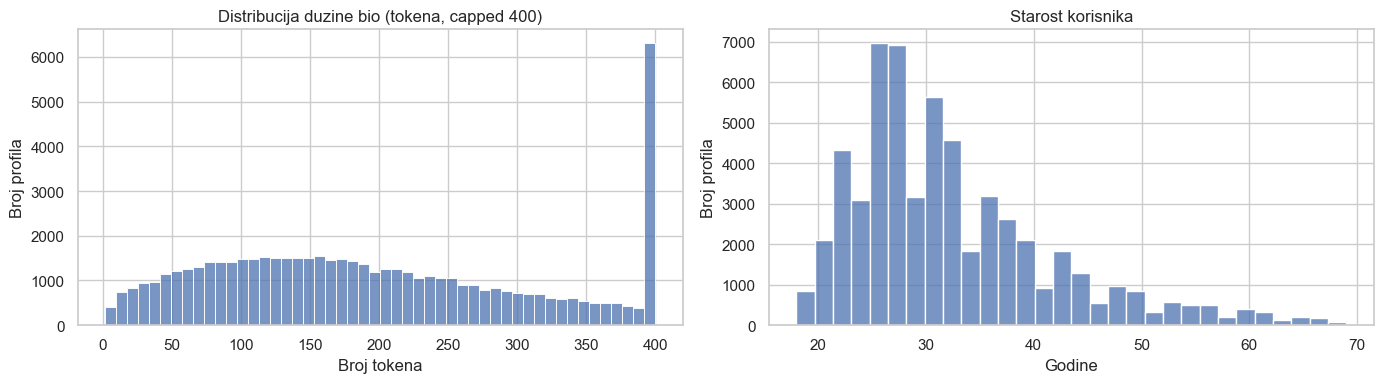

In [8]:
bios['n_tokens'] = bios['tokens_str'].fillna('').str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(bios['n_tokens'].clip(upper=400), bins=50, ax=axes[0])
axes[0].set_title('Distribucija duzine bio (tokena, capped 400)')
axes[0].set_xlabel('Broj tokena')
axes[0].set_ylabel('Broj profila')
if 'age' in bios.columns:
    sns.histplot(bios['age'].clip(18, 70), bins=30, ax=axes[1])
    axes[1].set_title('Starost korisnika')
    axes[1].set_xlabel('Godine')
    axes[1].set_ylabel('Broj profila')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_bios_length_age.png', dpi=150, bbox_inches='tight')
plt.show()

Distribucija dužine bio tekstova je desno asimetrična — većina profila ima između 20 i 100 tokena, uz manji broj znatno dužih. Starosna distribucija je koncentrisana u rasponu 22–35 godina, što odgovara tipičnom profilu korisnika dating aplikacija.

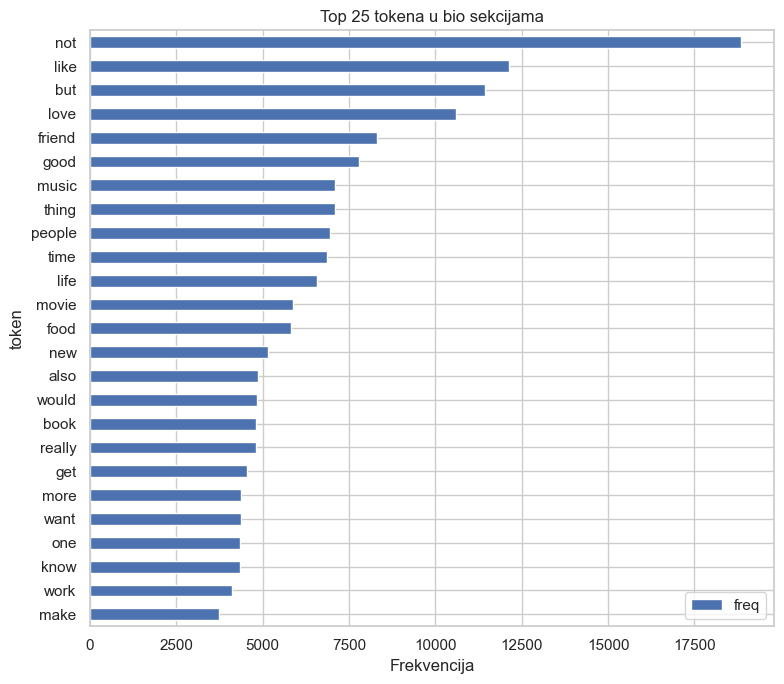

In [9]:
all_tokens = ' '.join(bios['tokens_str'].dropna().sample(min(5000, len(bios)), random_state=42)).split()
top = Counter(all_tokens).most_common(25)
fig, ax = plt.subplots(figsize=(8, 7))
pd.DataFrame(top, columns=['token', 'freq']).set_index('token').plot.barh(ax=ax)
ax.set_title('Top 25 tokena u bio sekcijama')
ax.invert_yaxis()
ax.set_xlabel('Frekvencija')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_bios_top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

Najfrekventniji tokeni odgovaraju tipičnom sadržaju dating profila — opisi interesa, aktivnosti i osobina. Odsustvo URL-ova, e-mailova i numeričkih tokena potvrđuje da je preprocesiranje uspješno uklonilo šum a zadržalo semantički relevantan sadržaj.

## 2. Govor mržnje

In [10]:
hate = pd.read_csv(PROCESSED / 'hate_speech_clean.csv')
print(hate.shape)
print(hate['label'].value_counts(normalize=True))
hate.head(3)

(37171, 5)
label
0    0.819402
1    0.180598
Name: proportion, dtype: float64


,text,text_clean,tokens_str,label,source
0,!!! RT @mayasolovely: As a woman you shouldn't...,!! rt <user> : as a woman you should not compl...,rt user woman not complain cleaning house man ...,0,davidson
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!! rt <user> : boy dats coldtyga dwn bad for c...,rt user boy dat coldtyga dwn bad cuffin dat ho...,0,davidson
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!! rt <user> dawg!! rt <user> : you ever fuck ...,rt user dawg rt user ever fuck bitch start cry...,0,davidson


Dataset broji **37 171** primjera iz dva izvora (Davidson 2017 i tweet\_eval). Klase su nebalansirane — udio govora mržnje iznosi ~18%, što je prirodna distribucija za ovakve datasete i ne iznenađuje. Na ovo treba obratiti pažnju pri treniranju modela, npr. kroz class weighting ili resampling.

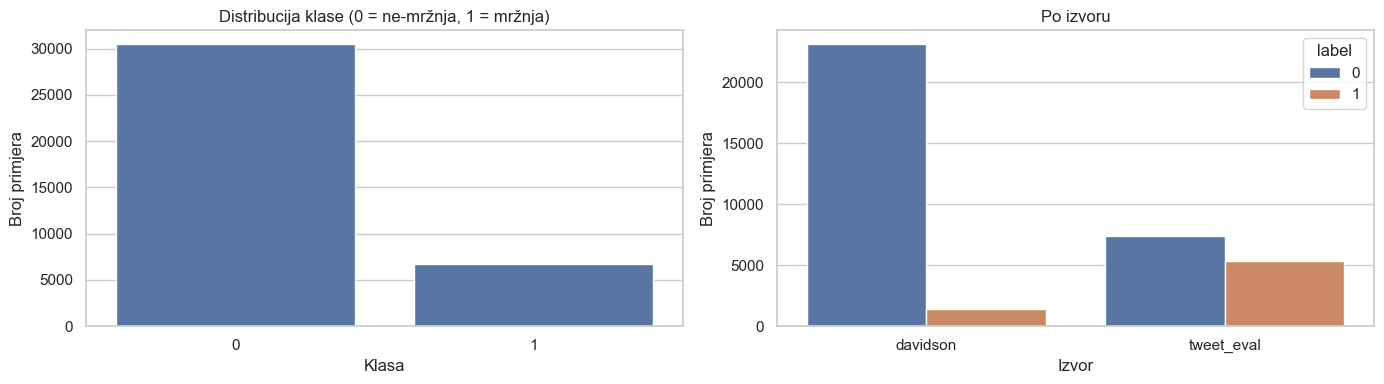

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=hate, x='label', ax=axes[0])
axes[0].set_title('Distribucija klase (0 = ne-mržnja, 1 = mržnja)')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj primjera')
if 'source' in hate.columns:
    sns.countplot(data=hate, x='source', hue='label', ax=axes[1])
    axes[1].set_title('Po izvoru')
    axes[1].set_xlabel('Izvor')
    axes[1].set_ylabel('Broj primjera')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_hate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Nebalansiranost je konzistentna u oba izvora, što znači da nije artefakt jednog dataseta nego karakteristika teme.

## 3. Detekcija prevara / botova

In [12]:
scam = pd.read_csv(PROCESSED / 'scam_detection_clean.csv')
print(scam.shape)
print(scam.groupby('source')['label'].value_counts())
scam.head(3)

(6806, 10)
source          label
sms_spam        0        4503
                1         605
synthetic_scam  0        1064
                1         634
Name: count, dtype: int64


,text,label,source,text_clean,tokens_str,len_chars,len_tokens,has_url,has_phone,has_money
0,"Go until jurong point, crazy.. Available only ...",0,sms_spam,go until jurong point crazy available only in ...,go jurong point crazy available bugis great wo...,111,14,0,0,0
1,Ok lar... Joking wif u oni...,0,sms_spam,ok lar joking wif you oni,ok lar joking wif oni,29,5,0,0,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,sms_spam,free entry in <NUM> a wkly comp to win fa cup ...,free entry NUM wkly comp win fa cup final tkts...,155,24,0,1,0


Dataset je sastavljen iz dva izvora s namjerno različitim karakteristikama. SMS Spam Collection (UCI) donosi realne kratke poruke s prirodnom distribucijom (~88% legitimnih, ~12% spam). Sintetički dio popunjava prazninu nedostajućih romance scam primjera — s uravnoteženijim omjerom legit/scam kako bi model bio adekvatno izložen oba tipa tokom treniranja.

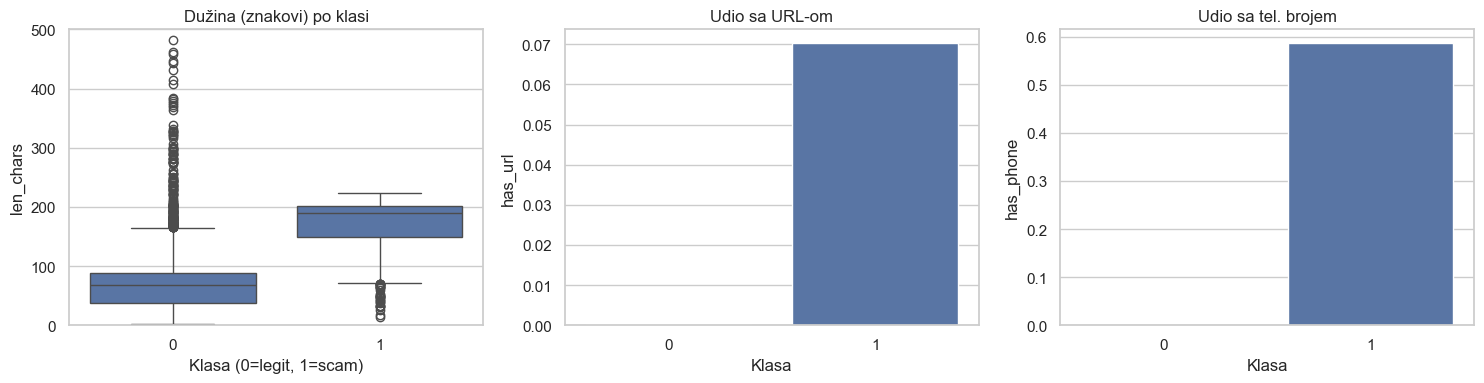

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=scam, x='label', y='len_chars', ax=axes[0])
axes[0].set_title('Dužina (znakovi) po klasi')
axes[0].set_ylim(0, 500)
axes[0].set_xlabel('Klasa (0=legit, 1=scam)')
sns.barplot(data=scam, x='label', y='has_url', ax=axes[1], errorbar=None)
axes[1].set_title('Udio sa URL-om')
axes[1].set_xlabel('Klasa')
sns.barplot(data=scam, x='label', y='has_phone', ax=axes[2], errorbar=None)
axes[2].set_title('Udio sa tel. brojem')
axes[2].set_xlabel('Klasa')
plt.tight_layout()
plt.savefig(REPORTS / 'eda_scam_features.png', dpi=150, bbox_inches='tight')
plt.show()

Grafici potvrđuju intuitivno očekivane razlike: spam/scam poruke su prosječno duže od legitimnih, a znatno češće sadrže telefonske brojeve i URL-ove. Ove karakteristike su direktno korisne kao features za klasifikator i dobro se vide već u sirovim podacima.

## 4. Sentiment — recenzije aplikacija

(6198, 6)
sentiment_label
negative    4712
positive    1143
neutral      343
Name: count, dtype: int64


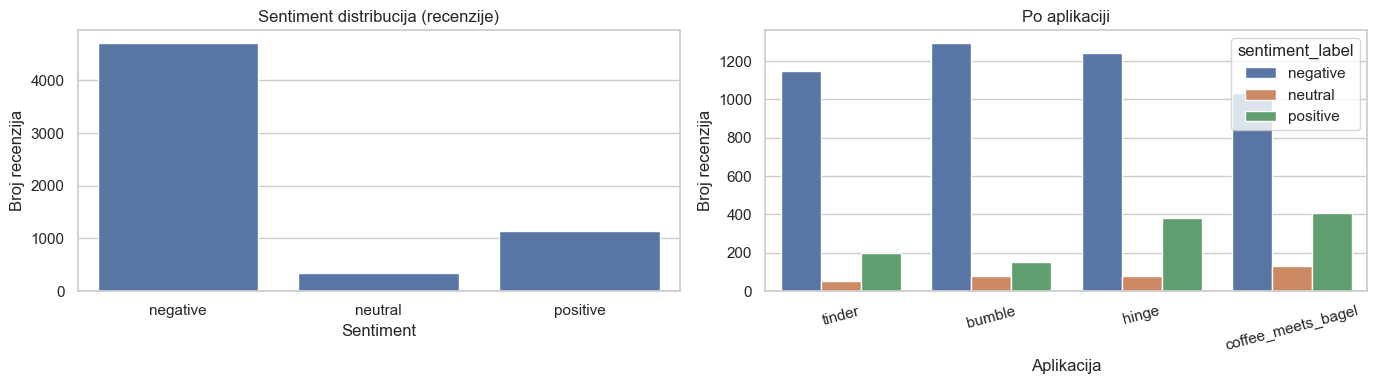

In [14]:
rev_path = PROCESSED / 'sentiment_reviews_clean.csv'
if rev_path.exists():
    rev = pd.read_csv(rev_path)
    print(rev.shape)
    print(rev['sentiment_label'].value_counts())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.countplot(data=rev, x='sentiment_label', order=['negative', 'neutral', 'positive'], ax=axes[0])
    axes[0].set_title('Sentiment distribucija (recenzije)')
    axes[0].set_xlabel('Sentiment')
    axes[0].set_ylabel('Broj recenzija')
    if 'app' in rev.columns:
        sns.countplot(data=rev, x='app', hue='sentiment_label', ax=axes[1])
        axes[1].set_title('Po aplikaciji')
        axes[1].set_xlabel('Aplikacija')
        axes[1].set_ylabel('Broj recenzija')
        axes[1].tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig(REPORTS / 'eda_sentiment_reviews.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Recenzije jos nisu skinute - pokreni scrape_tinder_reviews.')

Distribucija sentimenta je izrazito nagnuta prema negativnom — gotovo 76% recenzija spada u negativnu klasu, pozitivnih je ~18%, a neutralnih svega ~5.5%. Ovakav omjer je tipičan za recenzije mobilnih aplikacija, gdje korisnici znatno češće ostavljaju ocjenu kada su nezadovoljni. Na nebalansiranost klasa treba računati pri odabiru loss funkcije i metrika za evaluaciju.

## 5. Sentiment — sintetički razgovori

(2703, 7)
emotion
interested    458
neutral       456
sarcastic     306
happy         288
bored         157
disengaged    157
playful       153
polite        146
angry         146
frustrated    146
annoyed       146
excited       144
Name: count, dtype: int64


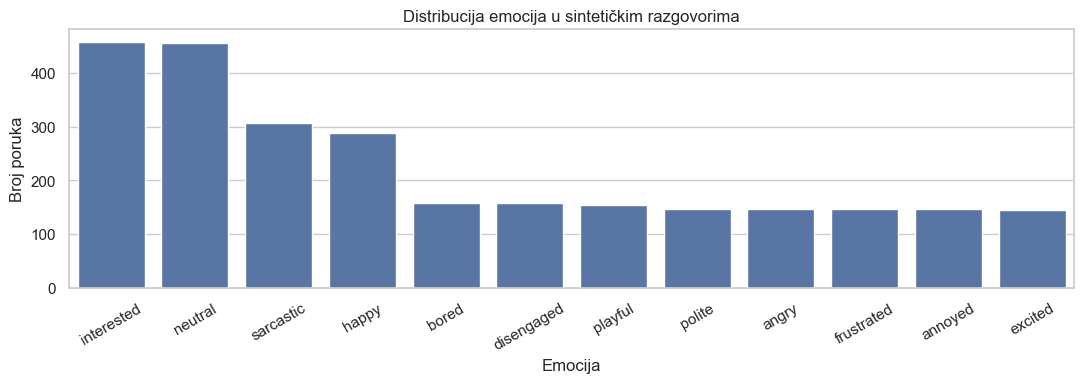

In [15]:
conv_path = PROCESSED / 'sentiment_conversations_clean.csv'
if conv_path.exists():
    conv = pd.read_csv(conv_path)
    print(conv.shape)
    print(conv['emotion'].value_counts())
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.countplot(data=conv, x='emotion', order=conv['emotion'].value_counts().index, ax=ax)
    ax.set_title('Distribucija emocija u sintetičkim razgovorima')
    ax.set_xlabel('Emocija')
    ax.set_ylabel('Broj poruka')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(REPORTS / 'eda_emotion_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Razgovori jos nisu generisani - pokreni generate_synthetic.')

Sintetički razgovori pokrivaju 12 emocionalnih stanja raspoređenih kroz četiri tipa konverzacijskih tokova: pad interesa, eskalacija frustracije, sarkazam i pozitivan match. Distribucija je relativno ujednačena zahvaljujući kontrolisanoj generaciji — `interested` i `neutral` su nešto zastupljenije jer se pojavljuju u više tokova.

## 6. Icebreaker — PersonaChat + Claude Haiku 4.5

Za icebreaker task korišten je **PersonaChat** dataset s Hugging Face-a (`awsaf49/persona-chat`) kao izvor persona. Iz dataseta je ekstrahovano 500 raznolikih persona pomoću KMeans klasterisanja nad Sentence-BERT embeddingima. Za svaku personu, Claude Haiku 4.5 je generisao kratki dating bio (maks. 2 rečenice) i jednu personaliziranu icebreaker poruku. Rezultat su JSONL fajlovi s train/eval splitom na nivou persona.

In [16]:
ICE_DIR = PROCESSED / 'icebreaker'
personas_path = ICE_DIR / 'personas.jsonl'
train_path = ICE_DIR / 'dataset_train.jsonl'
eval_path = ICE_DIR / 'dataset_eval.jsonl'

if not ICE_DIR.exists():
    print('[info] Icebreaker podaci jos nisu generisani.')
    print('  1. python -m src.icebreaker.extract_personas')
    print('  2. python -m src.icebreaker.generate_dataset')
else:
    # Personas
    if personas_path.exists():
        personas = [json.loads(l) for l in personas_path.read_text(encoding='utf-8').splitlines() if l.strip()]
        print(f'Persona: {len(personas)} jedinstvenih persona')
        avg_facts = sum(len(p['facts']) for p in personas) / len(personas)
        print(f'Prosjecno cinjenica po personi: {avg_facts:.2f}')
    else:
        personas = []
        print('[warn] personas.jsonl nije pronađen')

    # Train dataset
    records = []
    for path in [train_path, eval_path]:
        if path.exists():
            recs = [json.loads(l) for l in path.read_text(encoding='utf-8').splitlines() if l.strip()]
            for r in recs:
                bio_msg = r['messages'][0]['content']  # 'Bio: ...\nWrite an icebreaker.'
                ice_msg = r['messages'][1]['content']
                # Izvuci samo bio tekst
                bio_text = bio_msg.replace('Bio: ', '').split('\nWrite an icebreaker.')[0].strip()
                records.append({
                    'persona_id': r['persona_id'],
                    'temperature': r['temperature'],
                    'bio': bio_text,
                    'icebreaker': ice_msg,
                    'split': 'train' if path == train_path else 'eval',
                })

    if records:
        ice_df = pd.DataFrame(records)
        ice_df['bio_words'] = ice_df['bio'].str.split().str.len()
        ice_df['ice_words'] = ice_df['icebreaker'].str.split().str.len()
        print(f'\nDataset: {len(ice_df)} generisanih primjera')
        print(f'  train: {(ice_df.split == "train").sum()}, eval: {(ice_df.split == "eval").sum()}')
        print(f'  Bio duzina: median={ice_df.bio_words.median():.0f}, mean={ice_df.bio_words.mean():.1f} rijeci')
        print(f'  Icebreaker duzina: median={ice_df.ice_words.median():.0f}, mean={ice_df.ice_words.mean():.1f} rijeci')
        display(ice_df[['bio', 'icebreaker', 'temperature']].head(3))
    else:
        ice_df = None
        print('[warn] dataset_train.jsonl / dataset_eval.jsonl nisu pronađeni')

Persona: 500 jedinstvenih persona
Prosjecno cinjenica po personi: 4.26

Dataset: 1497 generisanih primjera
  train: 1272, eval: 225
  Bio duzina: median=26, mean=26.8 rijeci
  Icebreaker duzina: median=22, mean=22.6 rijeci


,bio,icebreaker,temperature
0,I've got a few iguanas keeping me company and ...,If you had to give a dog a name that sounds sa...,0.5
1,I've got a few iguanas keeping me company and ...,"If you had to teach a dog to read, what would ...",0.8
2,Proud iguana parent who believes dogs are just...,"If you had to teach your pet one human skill, ...",1.0


PersonaChat persone opisuju izmišljene karaktere s 3–5 činjenica (npr. `I like hiking`, `I have two cats`, `I work as a nurse`). Claude Haiku 4.5 je dobio zadatak da svaku personu repiše kao prirodni dating bio i doda jednu icebreaker poruku utemeljenu isključivo na datim činjenicama, bez izmišljanja novih detalja.

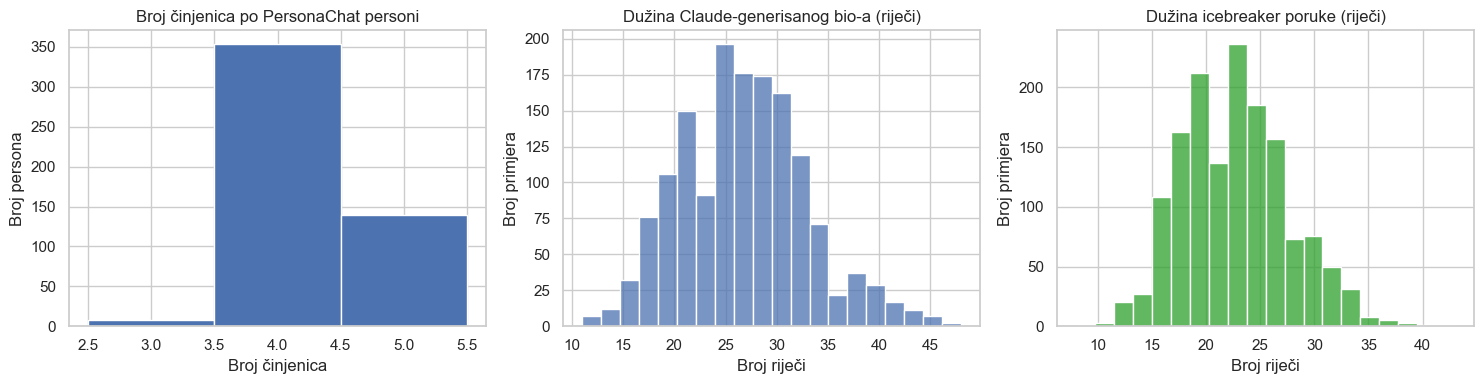

In [17]:
if personas:
    n_facts = [len(p['facts']) for p in personas]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Broj cinjenica po personi
    axes[0].hist(n_facts, bins=range(min(n_facts), max(n_facts) + 2), edgecolor='white', align='left')
    axes[0].set_title('Broj činjenica po PersonaChat personi')
    axes[0].set_xlabel('Broj činjenica')
    axes[0].set_ylabel('Broj persona')

    if ice_df is not None:
        # Bio duzina
        sns.histplot(ice_df['bio_words'], bins=20, ax=axes[1])
        axes[1].set_title('Dužina Claude-generisanog bio-a (riječi)')
        axes[1].set_xlabel('Broj riječi')
        axes[1].set_ylabel('Broj primjera')

        # Icebreaker duzina
        sns.histplot(ice_df['ice_words'], bins=20, ax=axes[2], color='#2ca02c')
        axes[2].set_title('Dužina icebreaker poruke (riječi)')
        axes[2].set_xlabel('Broj riječi')
        axes[2].set_ylabel('Broj primjera')
    else:
        axes[1].set_visible(False)
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.savefig(REPORTS / 'eda_icebreaker_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Nema podataka za prikaz — pokreni extract_personas i generate_dataset.')

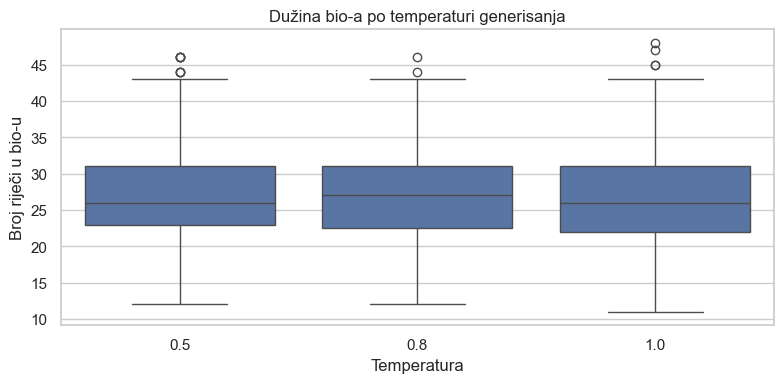

In [18]:
if ice_df is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(
        data=ice_df,
        x='temperature',
        y='bio_words',
        ax=ax,
        order=sorted(ice_df['temperature'].unique()),
    )
    ax.set_title('Dužina bio-a po temperaturi generisanja')
    ax.set_xlabel('Temperatura')
    ax.set_ylabel('Broj riječi u bio-u')
    plt.tight_layout()
    plt.savefig(REPORTS / 'eda_icebreaker_temp_vs_length.png', dpi=150, bbox_inches='tight')
    plt.show()

PersonaChat persone tipično imaju 3–5 činjenica, što je dovoljno da Claude generira kratak ali konkretan bio. Za razliku od Faker/šablon pristupa, ovdje svaki bio reflektuje različitu kombinaciju osobina i interesovanja, što rezultira vještački raznovrsnim ali koherentnim primjerima. Temperatura generisanja blago utječe na dužinu bio-a — viša temperatura tipski daje nešto duže i kreativnije odgovore.

In [19]:
if ice_df is not None:
    print('=== 5 primjera (različite persone) ===\n')
    sample = ice_df.drop_duplicates('persona_id').sample(min(5, len(ice_df)), random_state=42)
    for _, row in sample.iterrows():
        print(f'[persona_id={row.persona_id}, T={row.temperature}]')
        print(f'  Bio       : {row.bio}')
        print(f'  Icebreaker: {row.icebreaker}')
        print()

=== 5 primjera (različite persone) ===

[persona_id=274, T=0.5]
  Bio       : Marketing professional who's serious about finding someone to build a future with. I stay active and love what I do—looking for someone who's equally passionate about their own goals.
  Icebreaker: So if you had to market yourself to me in 30 seconds, what's your elevator pitch? 😄

[persona_id=269, T=0.5]
  Bio       : Freelance accountant who gets déjà vu more often than I'd like to admit. I'm a bit quiet in groups, but I come alive once a year when I escape to Florida.
  Icebreaker: Quick question: if you could only take one week off per year like me, would you also choose to spend it in Florida, or are you more adventurous than that?

[persona_id=490, T=0.5]
  Bio       : Data analyst by day, concert-goer by night, and perpetual steak enthusiast. Fair warning: I'm a devoted fan of anything that comes from a cow.
  Icebreaker: So on a scale of ribeye to wagyu, how do you feel about someone who'd choose a pe